# SARIMAX on R1 Hourly Delay

## Why SARIMAX instead of pure SARIMA?

The SARIMA baseline captured daily seasonality (period=24) in hourly mean delay.
However, the dataset contains additional structure that a pure univariate SARIMA ignores:

| Signal | Evidence from EDA |
|---|---|
| Hour-of-day pattern | Clear U-shaped delay curve: low 05-06h, peaks 09-11h and 20-23h |
| Workday vs weekend | Systematic level shift: weekends ~2 min less delay on average |
| Public holidays | Holidays behave like weekends but are calendar-driven |
| Temperature | Pearson r = +0.135, p < 0.001 on hourly aggregates |
| Windspeed | Small but consistent positive correlation |

SARIMAX (the X stands for eXogenous) incorporates these signals as external regressors
alongside the AR/MA/seasonal structure:

    delay_t = SARIMA(1,0,1)(1,0,1,24) + beta * X_t + eps_t

where X_t contains cyclic hour encoding, calendar flags, and weather variables.

### Why not a more complex model?

With 76 days of hourly data (~1 750 training hours) the dataset is:

- Too short for a reliable weekly seasonal period (s=168 needs >10 complete cycles)
- Too noisy for deep learning on this volume
- Already stationary (ADF/KPSS confirm d=0)

SARIMAX is the principled next step: it adds explanatory power through exogenous
variables without the estimation instability of larger seasonal orders.

## 0. Imports and Paths

In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import statsmodels.api as sm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from numpy.linalg import lstsq

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 100)

PROJECT_DIR = Path.cwd().resolve()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / "data" / "processed").exists():
    PROJECT_DIR = PROJECT_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        p for p in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", p.name)
    )
    if not candidates:
        raise FileNotFoundError("No features CSV found in data/processed/.")
    return candidates[-1]


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

## 1. Load Features and Build Hourly Series

### Why hourly aggregates?

89% of consecutive stop-to-stop delay deltas within a train journey are exactly 0
(delay is essentially constant within a journey). The real variance is *between* trains
and *across hours of the day*. Hourly aggregation is therefore the natural resolution.

### Cyclic encoding of periodic features

Raw integer hour (0-23) and day_of_week (0-6) create an artificial discontinuity
at the wrap-around point (hour 23 to 0, day 6 to 0). Sine/cosine pairs encode
the periodicity correctly:

    hour_sin = sin(2*pi*hour/24),  hour_cos = cos(2*pi*hour/24)

This ensures the model treats hour=23 and hour=0 as one hour apart, not 23 apart.

In [3]:
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

for col in ["planned_arrival_dt", "actual_arrival_dt", "hour_trunc", "service_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_model = df[df["direction"].notna()].copy()
print(f"Loaded: {features_path.name}")
print(f"Rows after direction filter: {len(df_model):,}")
print(f"Date range: {df_model['service_date'].min().date()} -> {df_model['service_date'].max().date()}")

# Aggregate to hourly level.
# delay_type_1 (actual minus FIRST planned arrival) is the main modelling target:
# it represents the true operational delay before Renfe adjusts the schedule.
# We also keep delay_type_2 and the type_1 - type_2 gap so exogenous
# relationships can be compared across all three delay variants.
hourly_raw = df_model.groupby("hour_trunc").agg(
    delay_type_1  = ("delay_type_1",   "mean"),
    delay_type_2  = ("target_delay",   "mean"),
    delay_type_1_minus_2 = ("delay_masking_minutes", "mean"),
    temperature   = ("temperature",    "mean"),
    windspeed     = ("windspeed",      "mean"),
    precipitation = ("precipitation",  "mean"),
    cloudcover    = ("cloudcover",     "mean"),
    is_weekend    = ("is_weekend",     "first"),
    is_holiday    = ("is_holiday",     "first"),
    hour          = ("hour",           "first"),
    day_of_week   = ("day_of_week",    "first"),
).sort_index()

# Cyclic encoding
hourly_raw["hour_sin"] = np.sin(2 * np.pi * hourly_raw["hour"] / 24)
hourly_raw["hour_cos"] = np.cos(2 * np.pi * hourly_raw["hour"] / 24)
hourly_raw["dow_sin"]  = np.sin(2 * np.pi * hourly_raw["day_of_week"] / 7)
hourly_raw["dow_cos"]  = np.cos(2 * np.pi * hourly_raw["day_of_week"] / 7)

# Reindex to complete hourly grid; fill overnight gaps (00:00-04:00)
# by time-weighted interpolation (~17% of the series)
full_idx = pd.date_range(hourly_raw.index.min(), hourly_raw.index.max(), freq="h")
hourly = hourly_raw.reindex(full_idx).interpolate(method="time").ffill().bfill()
hourly.index.name = "timestamp"
hourly["delay_type_1_2_mean"] = hourly[["delay_type_1", "delay_type_2"]].mean(axis=1)

SARIMAX_TARGET_SPECS = {
    "type_1_only": "delay_type_1",
    "type_2_only": "delay_type_2",
    "type_1_and_2": "delay_type_1_2_mean",
}

SARIMAX_TARGET_NOTES = {
    "type_1_only": "Type 1 = last actual arrival - first planned arrival.",
    "type_2_only": "Type 2 = last actual arrival - last planned arrival (= target_delay).",
    "type_1_and_2": "Type 1&2 = row-wise mean of Type 1 and Type 2.",
}

n_interp = hourly_raw.reindex(full_idx).isna().any(axis=1).sum()
print(f"\nFull hourly series: {len(hourly)} hours")
print(f"Overnight interpolated hours: {n_interp} ({n_interp/len(hourly)*100:.1f}%)")
print(f"Missing values after fill: {hourly.isna().sum().sum()}")

Loaded: features_20260607_171047.csv
Rows after direction filter: 273,405
Date range: 2026-03-15 -> 2026-05-21

Full hourly series: 1620 hours
Overnight interpolated hours: 286 (17.7%)
Missing values after fill: 0


## 2. Stationarity Tests

SARIMAX with d=0 assumes the series is stationary in the mean.
We verify with ADF and KPSS before fitting.

In [4]:
# Use delay_type_1 as the main target throughout this notebook.
target = hourly["delay_type_1"]

adf_stat, adf_p, *_ = adfuller(target.dropna(), autolag="AIC")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_stat, kpss_p, *_ = kpss(target.dropna(), regression="c", nlags="auto")

print("Stationarity Tests on Hourly Mean delay_type_1 (true operational delay)")
print(f"  ADF:  stat={adf_stat:.4f}  p={adf_p:.4f}  -> {'stationary' if adf_p < 0.05 else 'non-stationary'}")
print(f"  KPSS: stat={kpss_stat:.4f}  p={kpss_p:.4f}  -> {'non-stationary' if kpss_p < 0.05 else 'stationary'}")
if adf_p < 0.05 and kpss_p > 0.05:
    print("  Both agree: stationary. d=0 is valid.")
else:
    print("  Warning: tests disagree. Consider d=1.")

Stationarity Tests on Hourly Mean delay_type_1 (true operational delay)
  ADF:  stat=-5.4696  p=0.0000  -> stationary
  KPSS: stat=0.4121  p=0.0719  -> stationary
  Both agree: stationary. d=0 is valid.


## 3. Exogenous Variable Relevance

We verify that the candidate exogenous variables have a meaningful relationship
with the hourly delay target before including them in the model.

OLS R2 measures how much variance the exogenous variables explain in a simple
linear model, setting an upper bound on their contribution.

,target,ols_r2,ols_mae_min
0,type_1: actual - first planned,0.102,19.192
1,type_2: actual - last planned,0.054,2.943
2,type_1 - type_2: masking gap,0.101,17.844


,target,feature,coefficient,ci_lower,ci_upper,p_value,significant
0,type_1: actual - first planned,dow_sin,-2.1408,-3.8177,-0.4638,0.0124,yes
1,type_1: actual - first planned,dow_cos,0.8200,-0.8489,2.4889,0.3353,
2,type_1: actual - first planned,is_holiday,-5.2338,-10.8368,0.3691,0.0671,
3,type_1: actual - first planned,temperature,2.3222,1.9783,2.6660,0.0000,yes
4,type_2: actual - last planned,dow_sin,0.1163,-0.1906,0.4231,0.4575,
5,type_2: actual - last planned,dow_cos,1.0078,0.7024,1.3132,0.0000,yes
6,type_2: actual - last planned,is_holiday,-1.8820,-2.9072,-0.8568,0.0003,yes
7,type_2: actual - last planned,temperature,0.1787,0.1157,0.2416,0.0000,yes
8,type_1 - type_2: masking gap,dow_sin,-2.2570,-3.8122,-0.7019,0.0045,yes
9,type_1 - type_2: masking gap,dow_cos,-0.1878,-1.7355,1.3599,0.8119,


target,type_1 - type_2: masking gap,type_1: actual - first planned,type_2: actual - last planned
feature,,,
dow_cos,-0.003,0.027,0.165
dow_sin,-0.056,-0.046,0.030
is_holiday,-0.023,-0.040,-0.104
temperature,0.309,0.311,0.135


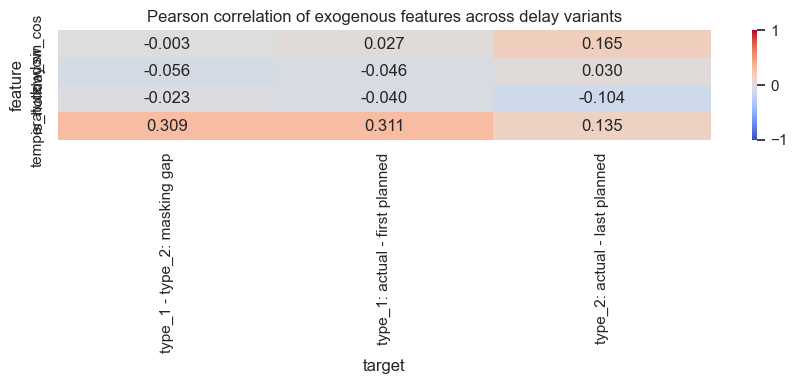

In [5]:
# hour_sin/cos are excluded: they encode the same 24h periodicity already
# captured by the seasonal AR/MA terms (ar.S.L24, ma.S.L24). Including both
# creates multicollinearity — the model cannot separately identify what share
# of the daily cycle is due to exog vs seasonal ARMA, which inflates standard
# errors and makes hour_sin/cos individually non-significant.
# Let the seasonal ARMA terms own the 24h cycle; keep only non-redundant signals.
EXOG_COLS = [
    "dow_sin",   "dow_cos",   # cyclic weekly pattern (non-redundant with s=24 terms)
    "is_holiday",             # step-level shift not capturable by day_of_week alone
    "temperature",            # +0.38 min/deg confirmed significant in previous run
]

DELAY_VARIANTS = {
    "delay_type_1": "type_1: actual - first planned",
    "delay_type_2": "type_2: actual - last planned",
    "delay_type_1_minus_2": "type_1 - type_2: masking gap",
}

X = sm.add_constant(hourly[EXOG_COLS])
exog_summary_rows = []
exog_corr_rows = []
exog_ols_rows = []

for target_col, target_label in DELAY_VARIANTS.items():
    y = hourly[target_col]
    ols_result = sm.OLS(y, X).fit()
    y_hat = ols_result.predict(X)
    r2 = ols_result.rsquared
    mae_linear = np.mean(np.abs(y - y_hat))
    exog_summary_rows.append({
        "target": target_label,
        "ols_r2": round(r2, 3),
        "ols_mae_min": round(mae_linear, 3),
    })

    conf_int = ols_result.conf_int()
    for feature in EXOG_COLS:
        exog_ols_rows.append({
            "target": target_label,
            "feature": feature,
            "coefficient": round(ols_result.params[feature], 4),
            "ci_lower": round(conf_int.loc[feature, 0], 4),
            "ci_upper": round(conf_int.loc[feature, 1], 4),
            "p_value": round(ols_result.pvalues[feature], 4),
            "significant": "yes" if ols_result.pvalues[feature] < 0.05 else "",
        })


    for feature in EXOG_COLS:
        r = np.corrcoef(hourly[target_col].values, hourly[feature].values)[0, 1]
        exog_corr_rows.append({
            "target": target_label,
            "feature": feature,
            "pearson_r": round(r, 3),
        })

exog_summary_df = pd.DataFrame(exog_summary_rows)
exog_corr_df = pd.DataFrame(exog_corr_rows)
exog_ols_df = pd.DataFrame(exog_ols_rows)

display(exog_summary_df)
display(exog_ols_df)
display(exog_corr_df.pivot(index="feature", columns="target", values="pearson_r"))

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    exog_corr_df.pivot(index="feature", columns="target", values="pearson_r"),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Pearson correlation of exogenous features across delay variants")
plt.tight_layout()
plt.show()

## 4. Train / Test Split

Temporal split: keep the last 10 service days as holdout (derived automatically
from the data range so it adapts as new data arrives). Everything before is
training data.

This mirrors real operational use: fitted on historical data, forecasts the near future.
A random split would leak future information and produce overly optimistic metrics.

Train: 2026-03-15 -> 2026-05-18  (1548 hours)
Test:  2026-05-19 -> 2026-05-21  (72 hours)
No overlap: True


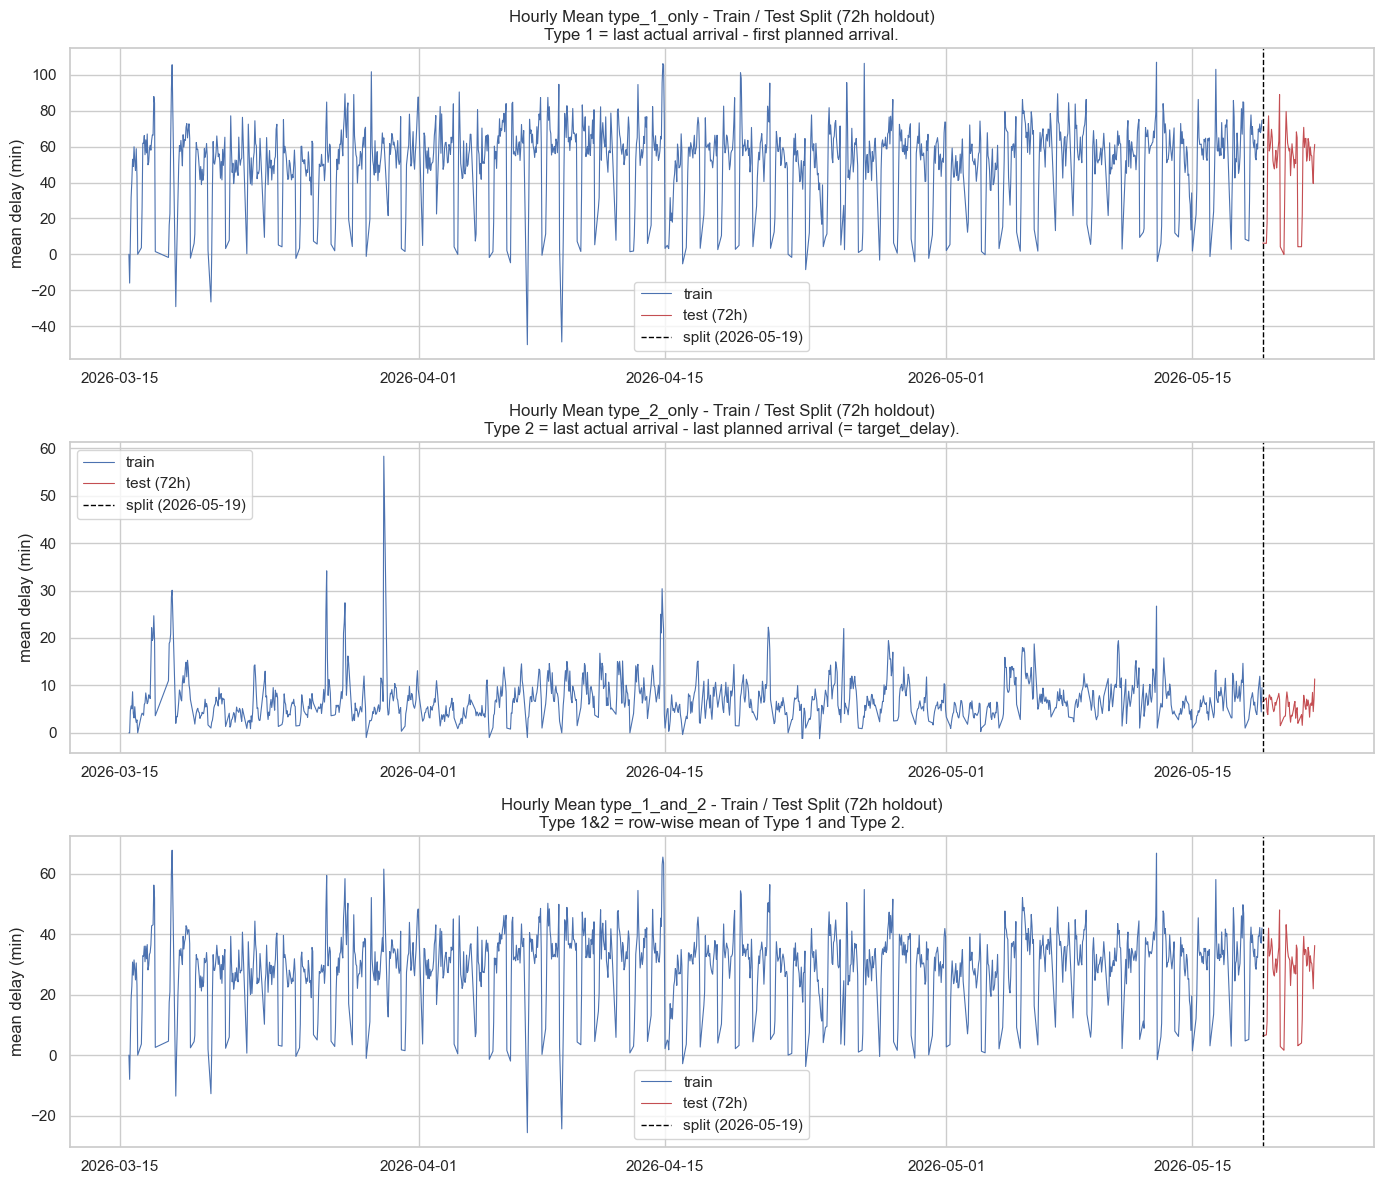

In [6]:
# Temporal split: last 72 hours as holdout — identical to the SARIMA notebook
# so that MAE/RMSE metrics are directly comparable across all three models.
#
# Previous version used a calendar cutoff (last ~264 hours) which gave SARIMAX
# a harder, longer test window than SARIMA. The comparison was not apple-to-apple.
# Using the same iloc[-72:] strategy ensures both models are evaluated on the
# same horizon length.
FORECAST_HORIZON = 72

train_frame = hourly.iloc[:-FORECAST_HORIZON].copy()
test_frame  = hourly.iloc[-FORECAST_HORIZON:].copy()

# Verify no overlap
assert len(set(train_frame.index) & set(test_frame.index)) == 0, "Overlap between train and test!"

print(f"Train: {train_frame.index.min().date()} -> {train_frame.index.max().date()}  ({len(train_frame)} hours)")
print(f"Test:  {test_frame.index.min().date()} -> {test_frame.index.max().date()}  ({len(test_frame)} hours)")
print(f"No overlap: {len(set(train_frame.index) & set(test_frame.index)) == 0}")

train_test_splits = {
    label: (train_frame[target_col].copy(), test_frame[target_col].copy())
    for label, target_col in SARIMAX_TARGET_SPECS.items()
}

# Convenience aliases used by downstream cells for the main target.
train = train_frame
test  = test_frame

fig, axes = plt.subplots(len(SARIMAX_TARGET_SPECS), 1, figsize=(14, 4 * len(SARIMAX_TARGET_SPECS)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (label, target_col) in zip(axes, SARIMAX_TARGET_SPECS.items()):
    ax.plot(train.index, train[target_col], color="#4C72B0", label="train", linewidth=0.8)
    ax.plot(test.index,  test[target_col],  color="#C44E52", label="test (72h)", linewidth=0.8)
    ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1,
               label=f"split ({test.index.min().date()})")
    ax.set_title(f"Hourly Mean {label} - Train / Test Split (72h holdout)\n{SARIMAX_TARGET_NOTES[label]}")
    ax.set_ylabel("mean delay (min)")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Baseline Forecasts

Two naive baselines establish the performance floor that SARIMAX must beat:

1. **Mean baseline**: predict training mean for every test hour. Represents the absolute floor.
2. **Seasonal-naive (7-day lag)**: predict each test hour using the observed value from the
   same hour exactly 7 days earlier. Captures weekly seasonality without fitting anything.
   A model that cannot beat this is not learning anything beyond the weekly pattern.

In [7]:
baseline_predictions = {}
baseline_rows = []

for label, target_col in SARIMAX_TARGET_SPECS.items():
    train_series, test_series = train_test_splits[label]
    train_mean_label = float(train_series.mean())
    pred_mean_label = pd.Series(train_mean_label, index=test_series.index)

    seasonal_preds = []
    for ts in test_series.index:
        lag_ts = ts - pd.Timedelta(days=7)
        seasonal_preds.append(train_series.get(lag_ts, train_mean_label))
    pred_seasonal_naive_label = pd.Series(seasonal_preds, index=test_series.index)

    baseline_predictions[label] = {
        "train_mean": train_mean_label,
        "pred_mean_baseline": pred_mean_label,
        "pred_seasonal_naive": pred_seasonal_naive_label,
    }
    baseline_rows.append({
        "target_variant": label,
        "mae_mean_baseline": mae(test_series, pred_mean_label),
        "rmse_mean_baseline": rmse(test_series, pred_mean_label),
        "mae_seasonal_naive_7d": mae(test_series, pred_seasonal_naive_label),
        "rmse_seasonal_naive_7d": rmse(test_series, pred_seasonal_naive_label),
    })

# Convenience aliases used by downstream cells for the main target.
train_mean = baseline_predictions["type_1_only"]["train_mean"]
pred_mean_baseline = baseline_predictions["type_1_only"]["pred_mean_baseline"]
pred_seasonal_naive = baseline_predictions["type_1_only"]["pred_seasonal_naive"]

baselines = pd.DataFrame(baseline_rows)
display(baselines.round(3))
print("Each SARIMAX target should beat its own seasonal_naive_7d baseline to justify model complexity.")

,target_variant,mae_mean_baseline,rmse_mean_baseline,mae_seasonal_naive_7d,rmse_seasonal_naive_7d
0,type_1_only,20.970,25.270,8.452,10.608
1,type_2_only,1.891,2.447,2.623,3.893
2,type_1_and_2,10.717,13.232,4.949,6.464


Each SARIMAX target should beat its own seasonal_naive_7d baseline to justify model complexity.


## 6. ACF / PACF of Training Series

Inspecting lags up to 168 (one full week) to guide order selection:
- Spikes at 24, 48, 72 -> daily seasonality present -> (P,D,Q,24) is appropriate
- Spikes at 168 -> residual weekly structure
- Quickly decaying non-seasonal lags -> low p,q orders are sufficient

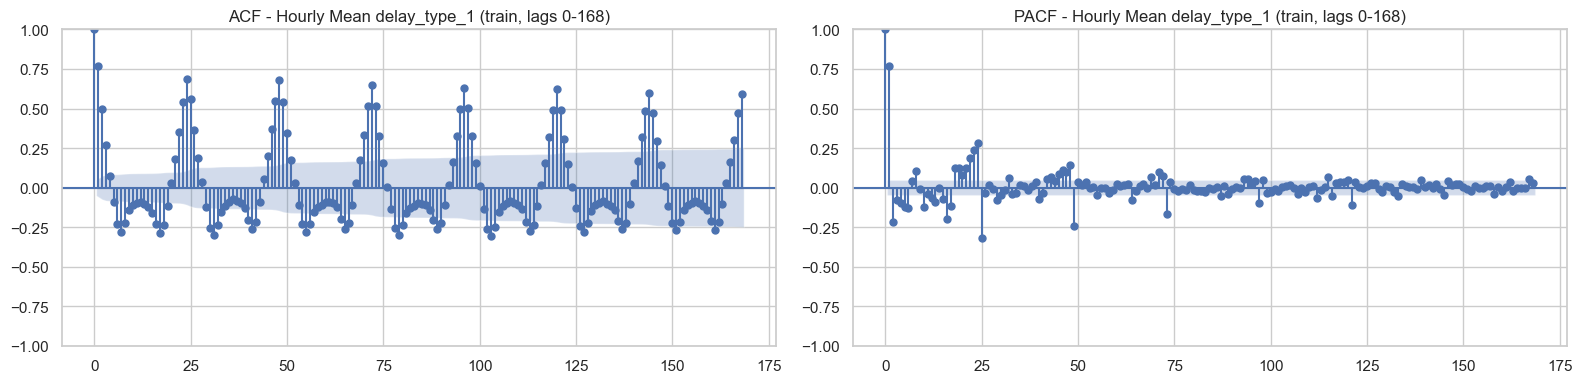

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( train["delay_type_1"].dropna(), lags=168, ax=axes[0])
axes[0].set_title("ACF - Hourly Mean delay_type_1 (train, lags 0-168)")
plot_pacf(train["delay_type_1"].dropna(), lags=168, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Hourly Mean delay_type_1 (train, lags 0-168)")
plt.tight_layout()
plt.show()

## 7. Fit SARIMAX Model

### Model specification

    delay_t = mu
            + phi_1 * delay_{t-1} + theta_1 * eps_{t-1}          [AR(1) MA(1)]
            + Phi_1 * delay_{t-24} + Theta_1 * eps_{t-24}         [seasonal s=24]
            + beta * X_t                                           [exogenous]
            + eps_t

### Exogenous regressors X_t

| Variable | Rationale |
|---|---|
| hour_sin, hour_cos | Cyclic hour-of-day - intraday U-shaped delay curve |
| dow_sin, dow_cos | Cyclic day-of-week - weekly rhythm beyond weekend flag |
| is_weekend | Step-level shift on Saturdays and Sundays |
| is_holiday | Holidays behave like weekends but are not captured by day_of_week |
| temperature | Positive correlation with delay (p < 0.001 in EDA) |
| windspeed | Small positive effect; retained because significant in EDA |

### Why enforce_stationarity=False?

The stationarity tests confirmed d=0 is valid. Setting this to False allows
the optimizer to explore near-boundary parameter regions; combined with d=0
this is safe and avoids premature convergence.

In [9]:
# Reduced exog set: hour_sin/cos removed (collinear with seasonal ARMA),
# windspeed removed (p=0.75 in previous run — not significant).
# Remaining: dow_sin/cos (weekly cycle), is_holiday, temperature.
EXOG_COLS = [
    "dow_sin",   "dow_cos",
    "is_holiday",
    "temperature",
]

sarimax_results = {}

print("Fitting SARIMAX(1,0,1)(1,0,1,24) with reduced exogenous regressors for all target variants...")
print(f"Exogenous columns: {EXOG_COLS}")
print()
print("Rationale for each included variable:")
print("  temperature : weather effect to be re-estimated separately for each target")
print("  dow_sin/cos : weekly cycle beyond what seasonal ARMA at s=24 captures")
print("  is_holiday  : step-level shift on holidays not encoded by day_of_week")
print()
print("Excluded vs previous run:")
print("  hour_sin/cos : collinear with ar.S.L24/ma.S.L24 — inflated std errors")
print("  windspeed    : p=0.750 — not significant")

for label, target_col in SARIMAX_TARGET_SPECS.items():
    print(f"\n=== {label} ===")
    train_endog_label = train[target_col]
    test_endog_label = test[target_col]
    train_exog_label = train[EXOG_COLS]
    test_exog_label = test[EXOG_COLS]

    model = SARIMAX(
        train_endog_label,
        exog=train_exog_label,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result_label = model.fit(
            disp=False,
            method="lbfgs",
            maxiter=500,
            optim_complex_step=False,
            optim_hessian="oim",
        )
        convergence_warnings = [
            w for w in caught
            if issubclass(w.category, UserWarning) and "converge" in str(w.message).lower()
        ]
        if convergence_warnings:
            print("WARNING: lbfgs did not converge. Trying bfgs fallback...")
            result_label = model.fit(
                disp=False,
                method="bfgs",
                maxiter=1000,
                optim_complex_step=False,
            )

    sarimax_results[label] = {
        "result": result_label,
        "train_endog": train_endog_label,
        "test_endog": test_endog_label,
        "train_exog": train_exog_label,
        "test_exog": test_exog_label,
    }
    print(result_label.summary())

# Convenience aliases used by downstream cells for the main target.
result = sarimax_results["type_1_only"]["result"]
train_endog = sarimax_results["type_1_only"]["train_endog"]
test_endog = sarimax_results["type_1_only"]["test_endog"]
train_exog = sarimax_results["type_1_only"]["train_exog"]
test_exog = sarimax_results["type_1_only"]["test_exog"]

Fitting SARIMAX(1,0,1)(1,0,1,24) with reduced exogenous regressors for all target variants...
Exogenous columns: ['dow_sin', 'dow_cos', 'is_holiday', 'temperature']

Rationale for each included variable:
  temperature : weather effect to be re-estimated separately for each target
  dow_sin/cos : weekly cycle beyond what seasonal ARMA at s=24 captures
  is_holiday  : step-level shift on holidays not encoded by day_of_week

Excluded vs previous run:
  hour_sin/cos : collinear with ar.S.L24/ma.S.L24 — inflated std errors
  windspeed    : p=0.750 — not significant

=== type_1_only ===
                                     SARIMAX Results                                      
Dep. Variable:                       delay_type_1   No. Observations:                 1548
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -5728.059
Date:                            Mon, 08 Jun 2026   AIC                          11474.118
Time:                                    15:58:2

## 8. Forecast on Holdout

We forecast the full test window using known future exogenous values
(hour of day, calendar flags, weather from the test data).

In operational deployment these would need to come from forecasts.
The 95% confidence interval reflects uncertainty in the ARMA residuals only.

,target_variant,mae_seasonal_naive_7d,rmse_seasonal_naive_7d,mae_sarimax,rmse_sarimax,mae_improvement_pct,rmse_improvement_pct
0,type_1_only,8.452,10.608,6.847,8.170,19.0,23.0
1,type_2_only,2.623,3.893,2.366,2.747,9.8,29.4
2,type_1_and_2,4.949,6.464,3.631,4.416,26.6,31.7


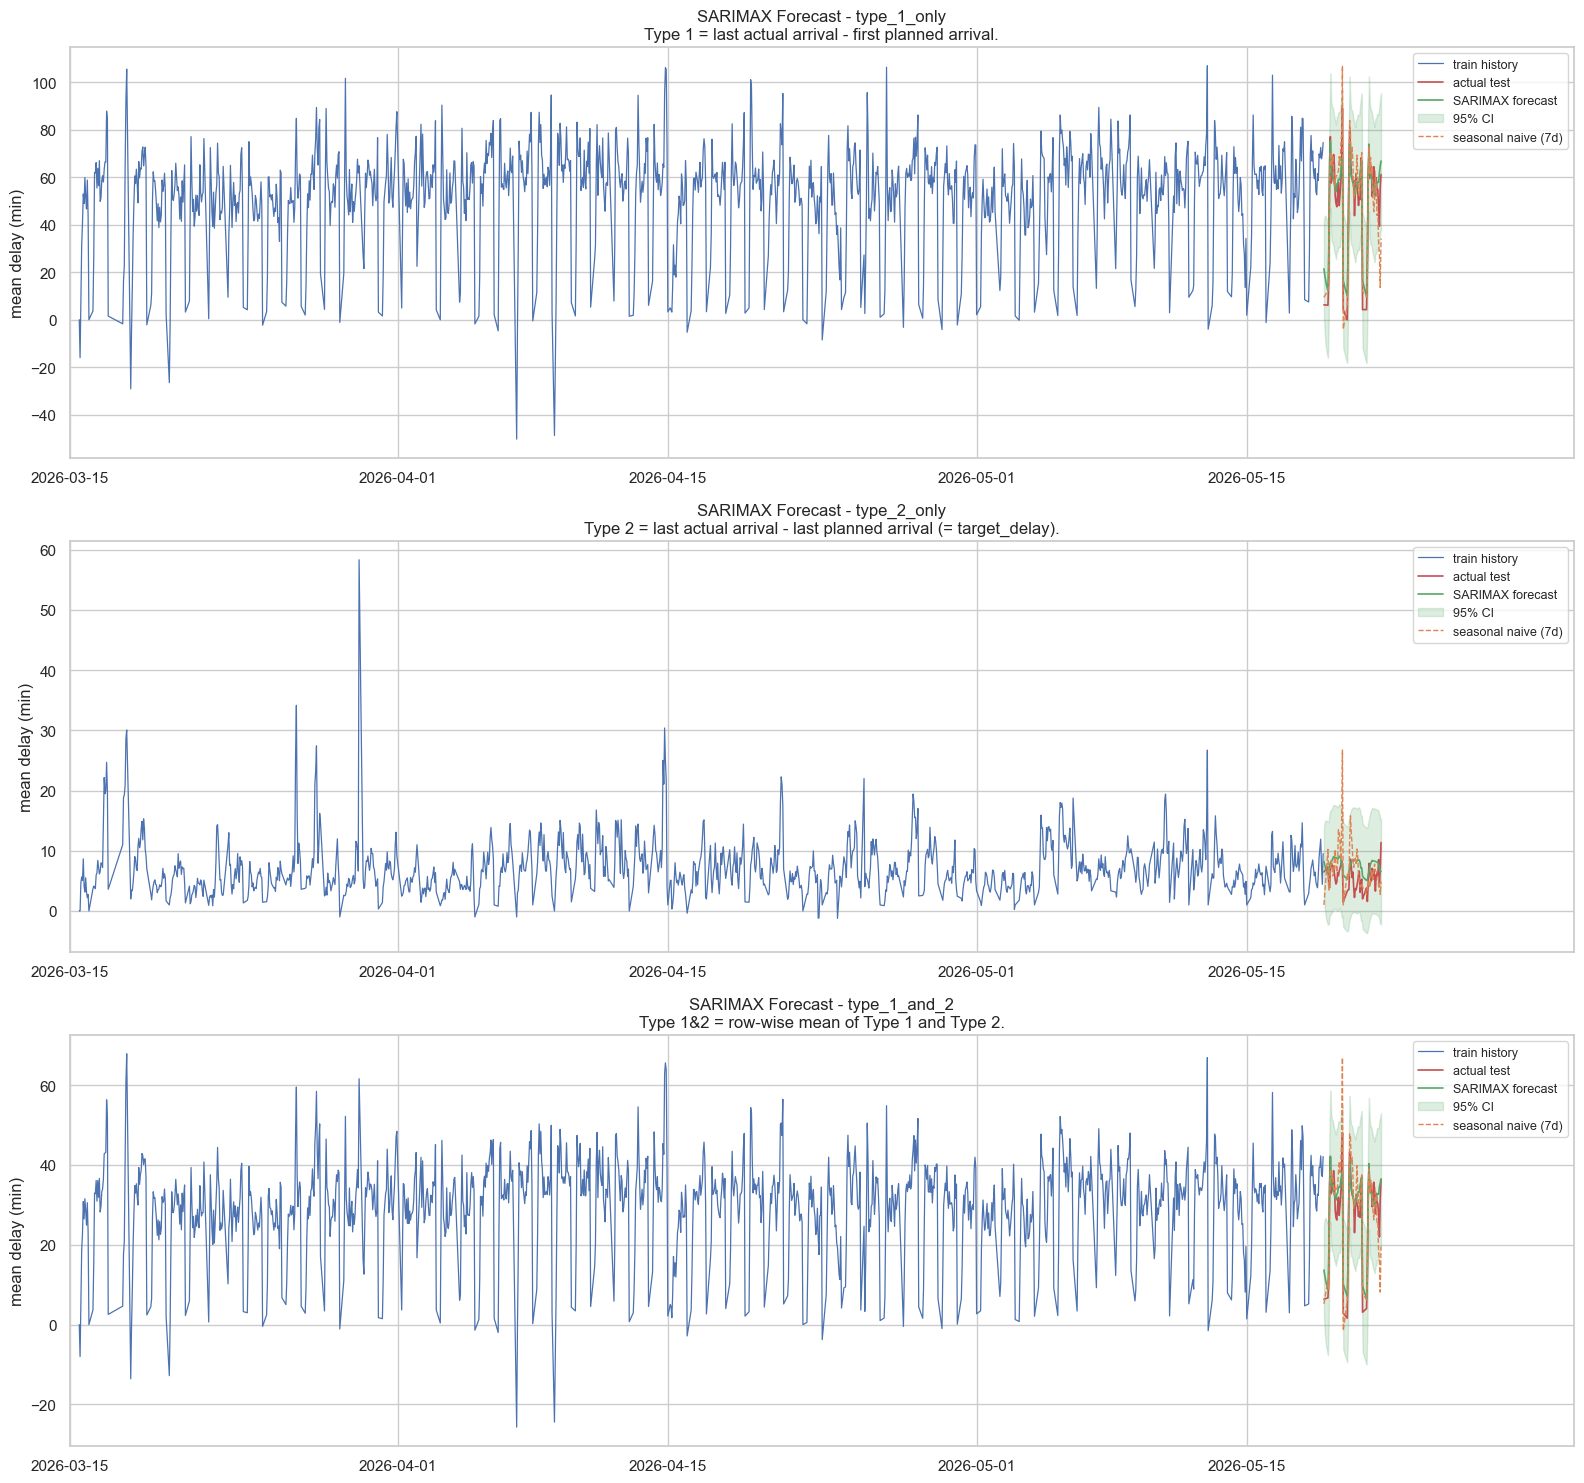

In [10]:
forecast_outputs = {}
comparison_rows = []

for label, target_col in SARIMAX_TARGET_SPECS.items():
    bundle = sarimax_results[label]
    forecast_obj_label = bundle["result"].get_forecast(
        steps=len(bundle["test_endog"]),
        exog=bundle["test_exog"],
    )
    pred_mean_label = forecast_obj_label.predicted_mean
    conf_int_label = forecast_obj_label.conf_int()
    pred_seasonal_naive_label = baseline_predictions[label]["pred_seasonal_naive"]
    forecast_outputs[label] = (pred_mean_label, conf_int_label, pred_seasonal_naive_label)

    sarimax_mae_label = mae(bundle["test_endog"], pred_mean_label)
    sarimax_rmse_label = rmse(bundle["test_endog"], pred_mean_label)
    naive_mae_label = mae(bundle["test_endog"], pred_seasonal_naive_label)
    naive_rmse_label = rmse(bundle["test_endog"], pred_seasonal_naive_label)
    comparison_rows.append({
        "target_variant": label,
        "mae_seasonal_naive_7d": naive_mae_label,
        "rmse_seasonal_naive_7d": naive_rmse_label,
        "mae_sarimax": sarimax_mae_label,
        "rmse_sarimax": sarimax_rmse_label,
        "mae_improvement_pct": round(100 * (naive_mae_label - sarimax_mae_label) / naive_mae_label, 1),
        "rmse_improvement_pct": round(100 * (naive_rmse_label - sarimax_rmse_label) / naive_rmse_label, 1),
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3))

# Convenience aliases used by downstream cells for the main target.
pred_mean, conf_int, pred_seasonal_naive = forecast_outputs["type_1_only"]
sarimax_mae = float(comparison.loc[comparison["target_variant"] == "type_1_only", "mae_sarimax"].iloc[0])
sarimax_rmse = float(comparison.loc[comparison["target_variant"] == "type_1_only", "rmse_sarimax"].iloc[0])

plot_start = pd.Timestamp("2026-03-15")
plot_end = pd.Timestamp("2026-05-31 23:00:00")

fig, axes = plt.subplots(len(SARIMAX_TARGET_SPECS), 1, figsize=(16, 5 * len(SARIMAX_TARGET_SPECS)), sharex=False)
axes = np.atleast_1d(axes)

for ax, label in zip(axes, SARIMAX_TARGET_SPECS):
    target_col = SARIMAX_TARGET_SPECS[label]
    pred_mean_label, conf_int_label, pred_seasonal_naive_label = forecast_outputs[label]
    ax.plot(train.index, train[target_col],
            label="train history", color="#4C72B0", linewidth=0.9)
    ax.plot(test.index, test[target_col],
            label="actual test", color="#C44E52", linewidth=1.2)
    ax.plot(pred_mean_label.index, pred_mean_label,
            label="SARIMAX forecast", color="#55A868", linewidth=1.2)
    ax.fill_between(conf_int_label.index, conf_int_label.iloc[:, 0], conf_int_label.iloc[:, 1],
                    color="#55A868", alpha=0.2, label="95% CI")
    ax.plot(test.index, pred_seasonal_naive_label,
            label="seasonal naive (7d)", color="#DD8452", linewidth=1, linestyle="--")
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(f"SARIMAX Forecast - {label}\n{SARIMAX_TARGET_NOTES[label]}")
    ax.set_ylabel("mean delay (min)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. Exogenous Coefficient Interpretation

The fitted beta coefficients show the marginal effect of each exogenous variable
on hourly mean delay, holding all other terms constant.

A positive coefficient means the variable is associated with higher delays.
Coefficients with p < 0.05 are statistically significant.

This fitted SARIMAX coefficient table is for delay_type_1 only.
The comparison plot below shows exogenous relationships for type_1, type_2, and type_1 - type_2.


,feature,coefficient,ci_lower,ci_upper,p_value,significant
0,dow_sin,-1.5438,-3.4520,0.3644,0.1128,
1,dow_cos,1.5455,-0.3613,3.4523,0.1122,
2,is_holiday,-5.5956,-10.3749,-0.8164,0.0217,yes
3,temperature,0.2502,-0.4354,0.9358,0.4744,


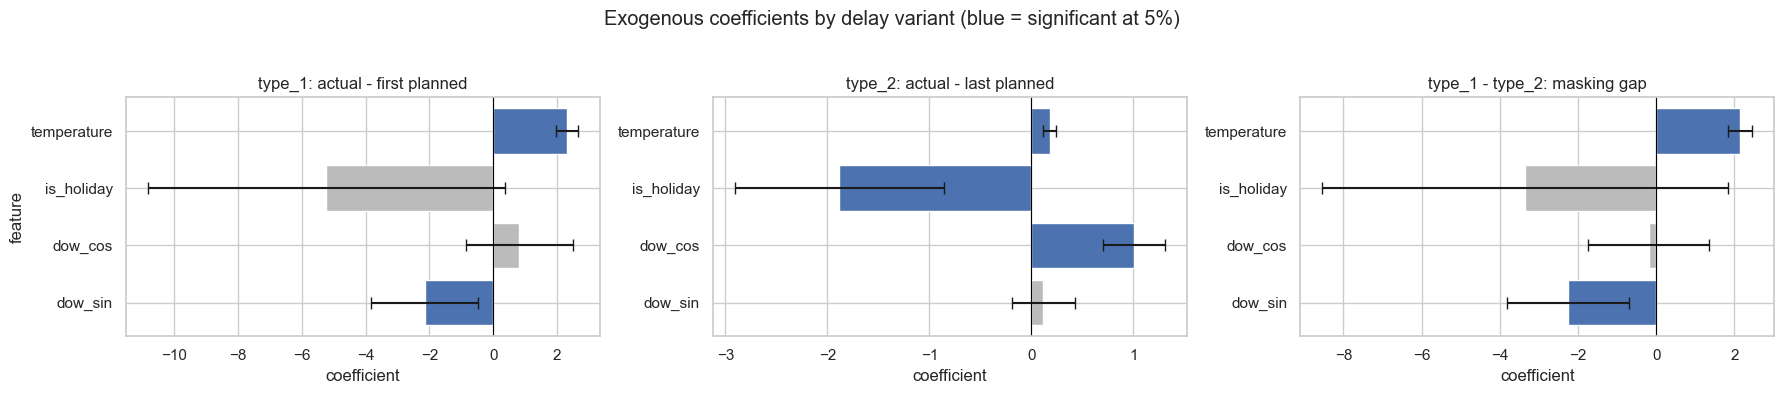

In [11]:
params = result.params
conf   = result.conf_int()
pvals = getattr(result, 'pvalues', pd.Series(dtype=float))

print("This fitted SARIMAX coefficient table is for delay_type_1 only.")
print("The comparison plot below shows exogenous relationships for type_1, type_2, and type_1 - type_2.")

conf_cols = list(conf.columns)
if 'lower' in conf_cols and 'upper' in conf_cols:
    lower_col, upper_col = 'lower', 'upper'
elif len(conf_cols) >= 2:
    lower_col, upper_col = conf_cols[0], conf_cols[1]
else:
    lower_col = upper_col = conf_cols[0]
rows = []
for col in EXOG_COLS:
    if col in params.index:
        rows.append({
            "feature":     col,
            "coefficient": round(params[col], 4),
            "ci_lower":    round(conf.loc[col, lower_col], 4),
            "ci_upper":    round(conf.loc[col, upper_col], 4),
            "p_value":     round(pvals[col], 4),
            "significant": "yes" if pvals[col] < 0.05 else "",
        })

exog_df = pd.DataFrame(rows)
display(exog_df)

fig, axes = plt.subplots(1, len(DELAY_VARIANTS), figsize=(18, 4), sharex=False)
axes = np.atleast_1d(axes)

for ax, (target_col, target_label) in zip(axes, DELAY_VARIANTS.items()):
    subset = exog_ols_df[exog_ols_df["target"] == target_label].copy()
    y_pos = range(len(subset))
    colors = ["#4C72B0" if p < 0.05 else "#BBBBBB" for p in subset["p_value"]]
    ax.barh(
        list(y_pos),
        subset["coefficient"],
        xerr=[
            subset["coefficient"] - subset["ci_lower"],
            subset["ci_upper"] - subset["coefficient"],
        ],
        color=colors,
        capsize=4,
    )
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(subset["feature"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(target_label)
    ax.set_xlabel("coefficient")

axes[0].set_ylabel("feature")
fig.suptitle("Exogenous coefficients by delay variant (blue = significant at 5%)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 10. Residual Diagnostics

Good residuals should be:
1. Approximately Gaussian - histogram centred near zero, bell-shaped
2. White noise - ACF bars within 95% bands; Ljung-Box p > 0.05
3. Homoscedastic - if variance is time-varying, GARCH on residuals would add value

Significant spikes at lag 24 -> unmodelled daily structure (raise P or Q).
Significant spikes at lag 168 -> weekly structure the exog variables did not fully capture.

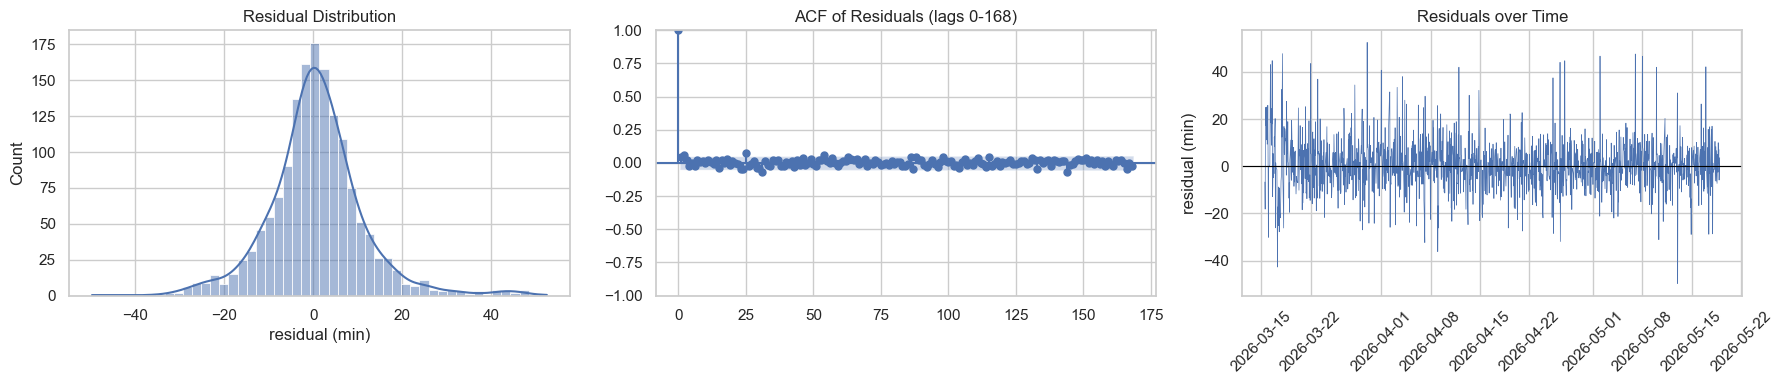

,lag,LB statistic,p-value,conclusion
0,24,25.001,0.4057,white noise (OK)
1,48,58.812,0.1363,white noise (OK)
2,168,163.650,0.5804,white noise (OK)


p > 0.05 -> residuals are white noise at this lag -> model is adequate
p <= 0.05 at lag 24 -> consider higher seasonal P or Q
p <= 0.05 at lag 168 -> weekly structure remains


In [12]:
resid = result.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(resid, bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("residual (min)")

plot_acf(resid, lags=168, ax=axes[1])
axes[1].set_title("ACF of Residuals (lags 0-168)")

axes[2].plot(resid.index, resid.values, color="#4C72B0", linewidth=0.5)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Residuals over Time")
axes[2].set_ylabel("residual (min)")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Ljung-Box test
lb_rows = []
for lag in [24, 48, 168]:
    if lag < len(resid):
        lb = acorr_ljungbox(resid, lags=[lag], return_df=True)
        lb_rows.append({
            "lag":          lag,
            "LB statistic": round(lb["lb_stat"].iloc[0], 3),
            "p-value":      round(lb["lb_pvalue"].iloc[0], 4),
            "conclusion":   "white noise (OK)" if lb["lb_pvalue"].iloc[0] > 0.05
                            else "autocorrelation remains",
        })
lb_df = pd.DataFrame(lb_rows)
display(lb_df)
print("p > 0.05 -> residuals are white noise at this lag -> model is adequate")
print("p <= 0.05 at lag 24 -> consider higher seasonal P or Q")
print("p <= 0.05 at lag 168 -> weekly structure remains")

## 11. Heteroscedasticity Check (ARCH Effects)

If the SARIMAX residuals show time-varying variance (volatility clustering),
a GARCH model on the residuals would add value.

ARCH-LM test: H0 = no ARCH effects (constant variance).
A small p-value rejects constant variance and motivates GARCH on the residuals.

ARCH-LM Test on SARIMAX Residuals
  LM statistic: 45.3465
  LM p-value:   0.0000

ARCH effects present (p < 0.05).
Recommendation: fit GARCH(1,1) on result.resid to model time-varying
uncertainty. This gives better confidence intervals than the SARIMAX CI alone.


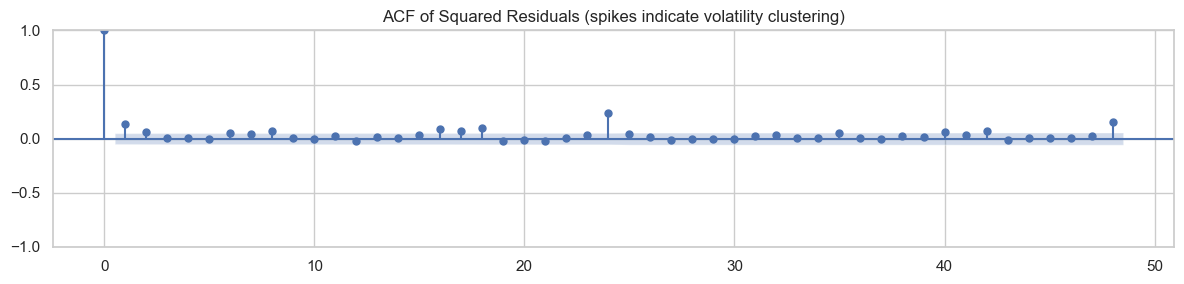

In [13]:
lm_stat, lm_p, f_stat, f_p = het_arch(resid.values, nlags=12)

print("ARCH-LM Test on SARIMAX Residuals")
print(f"  LM statistic: {lm_stat:.4f}")
print(f"  LM p-value:   {lm_p:.4f}")

if lm_p < 0.05:
    print()
    print("ARCH effects present (p < 0.05).")
    print("Recommendation: fit GARCH(1,1) on result.resid to model time-varying")
    print("uncertainty. This gives better confidence intervals than the SARIMAX CI alone.")
else:
    print()
    print("No significant ARCH effects (p >= 0.05).")
    print("Constant variance assumption is acceptable.")

# Visual ARCH check: ACF of squared residuals
fig, ax = plt.subplots(figsize=(12, 3))
plot_acf(resid**2, lags=48, ax=ax)
ax.set_title("ACF of Squared Residuals (spikes indicate volatility clustering)")
plt.tight_layout()
plt.show()

### Limitations

- 76 days of training is sufficient for SARIMAX but limits reliability of weekly estimates
- Weather is Barcelona-wide; station-specific effects are not captured
- The model forecasts mean delay across all R1 trains in an hour, not a specific train

### Natural next steps

1. SARIMAX + GARCH on residuals if ARCH effects are present
2. Direction-stratified models (separate SARIMAX for direction1 / direction2)
3. Rolling re-fit window for real-time deployment
4. Extended exogenous set: delay_masking_minutes as a systemic load indicator

In [14]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(4):
    if (PROJECT_ROOT / "data" / "models").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "data" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Pull the forecast for metrics ────────────────────────────────────────────
# `result`, `train`, `test`, `test_exog` are defined earlier in the notebook.
sarimax_pred = result.get_forecast(steps=len(test), exog=test_exog).predicted_mean

sarimax_export = {
    "spec": {
        "order":          [1, 0, 1],
        "seasonal_order": [1, 0, 1, 24],
        "target_variant": "type_1_only",
        "exog_cols":      EXOG_COLS,
        "enforce_stationarity": False,
        "enforce_invertibility": False,
    },
    "params": {k: float(v) for k, v in result.params.items()},
    # Last 48 rows of training endog + exog for warm-start
    "train_last_values": train["delay_type_1"].iloc[-48:].tolist(),
    "train_last_index":  [str(x) for x in train.index[-48:]],
    "train_last_exog":   train[EXOG_COLS].iloc[-48:].values.tolist(),
    # Per-column means used to keep the baseline forecast centred
    "exog_col_means":    {c: float(train[c].mean()) for c in EXOG_COLS},
    "train_mean":  float(train["delay_type_1"].mean()),
    "train_std":   float(train["delay_type_1"].std()),
    "train_start": str(train.index.min()),
    "train_end":   str(train.index.max()),
    "n_train":     len(train),
    "test_mae":    round(mae(test["delay_type_1"], sarimax_pred), 4),
    "test_rmse":   round(rmse(test["delay_type_1"], sarimax_pred), 4),
}

out_path = MODELS_DIR / "sarimax_params.json"
out_path.write_text(json.dumps(sarimax_export, indent=2))
print(f"   Saved {out_path}  ({out_path.stat().st_size // 1024} KB)")
print(f"   exog cols : {EXOG_COLS}")
print(f"   MAE       : {sarimax_export['test_mae']} min")
print(f"   RMSE      : {sarimax_export['test_rmse']} min")

   Saved /private/tmp/timeseries-analysis-latest-20260608/PROJECT/EDA/data/models/sarimax_params.json  (7 KB)
   exog cols : ['dow_sin', 'dow_cos', 'is_holiday', 'temperature']
   MAE       : 6.8473 min
   RMSE      : 8.1699 min
